# 01 - Exploratory Data Analysis

This notebook performs exploratory data analysis on the Amazon ESCI dataset for fine-grained e-commerce NER.

**Objectives:**
- Understand dataset structure and size
- Analyze query length distributions
- Explore entity type frequencies and distributions
- Identify common tokens per entity type
- Assess data quality and potential challenges

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from pathlib import Path
from typing import List, Dict, Tuple

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Paths
DATA_DIR = Path("../data/annotations")
PROCESSED_DIR = Path("../data/processed")
OUTPUT_DIR = Path("../results/eda")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete!")

Setup complete!


## 1. Load and Inspect Data

In [18]:
# Load train, validation, and test splits
train_df = pd.read_parquet(DATA_DIR / "train.parquet")
val_df = pd.read_parquet(DATA_DIR / "val.parquet")
test_df = pd.read_parquet(DATA_DIR / "test.parquet")

print("Dataset Sizes:")
print(f"  Train: {len(train_df):,} samples")
print(f"  Val:   {len(val_df):,} samples")
print(f"  Test:  {len(test_df):,} samples")
print(f"  Total: {len(train_df) + len(val_df) + len(test_df):,} samples")

# Combine for overall analysis
all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
print(f"\nCombined dataset: {len(all_df):,} samples")

Dataset Sizes:
  Train: 52,500 samples
  Val:   11,250 samples
  Test:  11,250 samples
  Total: 75,000 samples

Combined dataset: 75,000 samples


In [19]:
# Inspect columns and data types
print("Columns and Data Types:")
print(train_df.dtypes)
print(f"\nColumns: {train_df.columns.tolist()}")

Columns and Data Types:
query                   object
product_title           object
product_brand           object
product_color           object
product_bullet_point    object
product_description     object
esci_label              object
query_clean             object
query_tokens            object
num_tokens               int64
_stratum                object
ner_tags                object
dtype: object

Columns: ['query', 'product_title', 'product_brand', 'product_color', 'product_bullet_point', 'product_description', 'esci_label', 'query_clean', 'query_tokens', 'num_tokens', '_stratum', 'ner_tags']


In [20]:
# Display sample rows
print("Sample Data:")
display_cols = ['query', 'query_tokens', 'ner_tags', 'num_tokens']
train_df[display_cols].head(10)

Sample Data:


,query,query_tokens,ner_tags,num_tokens
0,animal crossing switch,"[animal, crossing, switch]","[B-COLOR, I-COLOR, B-PRODUCT_TYPE]",3
1,samsung tab s4 screen protector,"[samsung, tab, s4, screen, protector]","[O, O, O, O, O]",5
2,falcons flag,"[falcons, flag]","[B-PRODUCT_TYPE, B-PRODUCT_TYPE]",2
3,outdoor mats,"[outdoor, mats]","[B-ATTRIBUTE_VALUE, B-PRODUCT_TYPE]",2
4,dio body pillow,"[dio, body, pillow]","[O, B-PRODUCT_TYPE, I-PRODUCT_TYPE]",3
5,scott toilet paper,"[scott, toilet, paper]","[B-BRAND, O, O]",3
6,starbucks mocha,"[starbucks, mocha]","[B-BRAND, B-COLOR]",2
7,laziness does not exist,"[laziness, does, not, exist]","[O, B-PRODUCT_TYPE, I-PRODUCT_TYPE, I-PRODUCT_...",4
8,orange light weight safety vest,"[orange, light, weight, safety, vest]","[B-PRODUCT_TYPE, O, O, B-BRAND, O]",5
9,quintessential quintuplets,"[quintessential, quintuplets]","[O, O]",2


## 2. Query Length Analysis

In [21]:
# Compute query lengths
all_df['query_length_tokens'] = all_df['query_tokens'].apply(len)
all_df['query_length_chars'] = all_df['query'].str.len()

# Summary statistics
print("Query Length Statistics (Tokens):")
print(all_df['query_length_tokens'].describe())
print(f"\nQuery Length Statistics (Characters):")
print(all_df['query_length_chars'].describe())

Query Length Statistics (Tokens):
count    75000.000000
mean         3.669627
std          1.496593
min          2.000000
25%          3.000000
50%          3.000000
75%          4.000000
max         20.000000
Name: query_length_tokens, dtype: float64

Query Length Statistics (Characters):
count    75000.000000
mean        21.817573
std          8.731276
min          3.000000
25%         15.000000
50%         21.000000
75%         27.000000
max        138.000000
Name: query_length_chars, dtype: float64


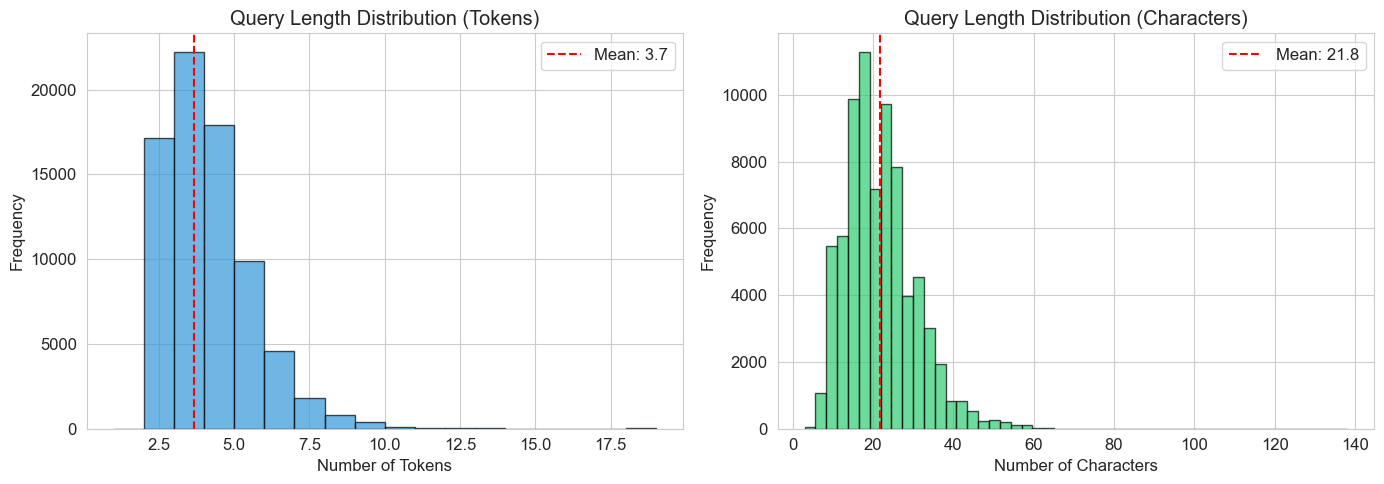

In [22]:
# Plot query length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(all_df['query_length_tokens'], bins=range(1, 20), edgecolor='black', alpha=0.7, color='#3498db')
axes[0].set_xlabel('Number of Tokens')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Query Length Distribution (Tokens)')
axes[0].axvline(all_df['query_length_tokens'].mean(), color='red', linestyle='--', label=f"Mean: {all_df['query_length_tokens'].mean():.1f}")
axes[0].legend()

axes[1].hist(all_df['query_length_chars'], bins=50, edgecolor='black', alpha=0.7, color='#2ecc71')
axes[1].set_xlabel('Number of Characters')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Query Length Distribution (Characters)')
axes[1].axvline(all_df['query_length_chars'].mean(), color='red', linestyle='--', label=f"Mean: {all_df['query_length_chars'].mean():.1f}")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "query_length_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

## 3. Entity Type Distribution

In [23]:
# Extract all entity tags (excluding 'O')
def extract_entity_types(ner_tags):
    entities = []
    for tag in ner_tags:
        if tag != 'O' and tag.startswith(('B-', 'I-')):
            entity_type = tag[2:]
            entities.append(entity_type)
    return entities

all_entities = []
for tags in all_df['ner_tags']:
    all_entities.extend(extract_entity_types(tags))

entity_counts = Counter(all_entities)
print("Entity Type Counts (Token-level):")
for entity, count in entity_counts.most_common():
    print(f"  {entity}: {count:,}")

Entity Type Counts (Token-level):
  PRODUCT_TYPE: 66,214
  BRAND: 18,192
  COLOR: 4,676
  ATTRIBUTE_VALUE: 3,544
  MATERIAL: 2,896
  SIZE_MEASURE: 2,846


In [24]:
# Count entity spans (B- tags only)
def count_entity_spans(ner_tags):
    spans = defaultdict(int)
    for tag in ner_tags:
        if tag.startswith('B-'):
            entity_type = tag[2:]
            spans[entity_type] += 1
    return dict(spans)

all_df['entity_spans'] = all_df['ner_tags'].apply(count_entity_spans)

span_counts = Counter()
for spans in all_df['entity_spans']:
    span_counts.update(spans)

print("Entity Span Counts (Entity-level):")
for entity, count in span_counts.most_common():
    print(f"  {entity}: {count:,} spans")

Entity Span Counts (Entity-level):
  PRODUCT_TYPE: 54,385 spans
  BRAND: 14,184 spans
  COLOR: 3,713 spans
  ATTRIBUTE_VALUE: 3,431 spans
  MATERIAL: 2,841 spans
  SIZE_MEASURE: 2,001 spans


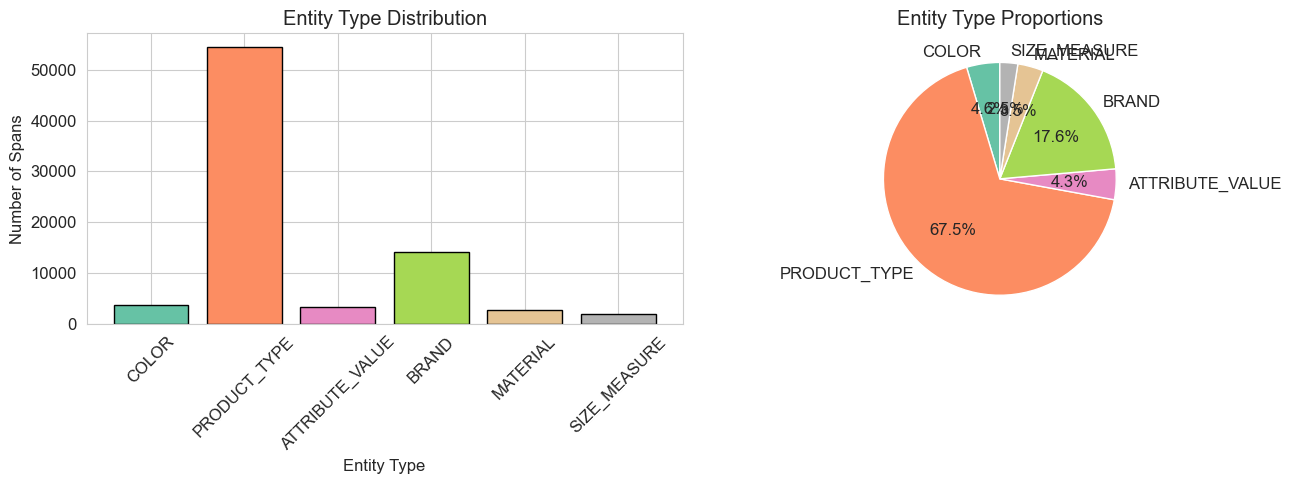

In [25]:
# Visualize entity distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

entities = list(span_counts.keys())
counts = list(span_counts.values())
colors = plt.cm.Set2(np.linspace(0, 1, len(entities)))

bars = axes[0].bar(entities, counts, color=colors, edgecolor='black')
axes[0].set_xlabel('Entity Type')
axes[0].set_ylabel('Number of Spans')
axes[0].set_title('Entity Type Distribution')
axes[0].tick_params(axis='x', rotation=45)

axes[1].pie(counts, labels=entities, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Entity Type Proportions')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "entity_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Entities Per Query Analysis

In [26]:
all_df['num_entities'] = all_df['entity_spans'].apply(lambda x: sum(x.values()))
all_df['num_entity_types'] = all_df['entity_spans'].apply(len)

print("Entities Per Query Statistics:")
print(f"  Mean entities per query: {all_df['num_entities'].mean():.2f}")
print(f"  Median entities per query: {all_df['num_entities'].median():.0f}")
print(f"  Max entities in a query: {all_df['num_entities'].max()}")
print(f"  Queries with no entities: {(all_df['num_entities'] == 0).sum():,}")

Entities Per Query Statistics:
  Mean entities per query: 1.07
  Median entities per query: 1
  Max entities in a query: 6
  Queries with no entities: 19,336


## 5. Token Analysis by Entity Type

In [27]:
entity_tokens = defaultdict(list)

for _, row in all_df.iterrows():
    tokens = row['query_tokens']
    tags = row['ner_tags']
    for token, tag in zip(tokens, tags):
        if tag != 'O':
            entity_type = tag[2:]
            entity_tokens[entity_type].append(token.lower())

print("Top 10 Tokens Per Entity Type:")
for entity_type in sorted(entity_tokens.keys()):
    token_counter = Counter(entity_tokens[entity_type])
    print(f"\n{entity_type}:")
    for token, count in token_counter.most_common(10):
        print(f"  {token}: {count:,}")

Top 10 Tokens Per Entity Type:

ATTRIBUTE_VALUE:
  led: 331
  outdoor: 312
  usb: 295
  wireless: 271
  electric: 211
  bluetooth: 194
  portable: 181
  waterproof: 175
  organic: 140
  indoor: 122

BRAND:
  nike: 263
  apple: 180
  lego: 163
  adidas: 145
  and: 115
  samsung: 98
  amazon: 91
  disney: 88
  hp: 82
  funko: 81

COLOR:
  black: 281
  white: 187
  gold: 121
  blue: 99
  red: 92
  clear: 63
  brown: 60
  silver: 52
  back: 51
  pink: 50

MATERIAL:
  glass: 245
  plastic: 238
  leather: 212
  metal: 169
  wood: 161
  cotton: 148
  foam: 131
  silicone: 128
  wooden: 128
  steel: 111

PRODUCT_TYPE:
  black: 734
  white: 685
  for: 557
  women: 509
  set: 464
  kids: 377
  kit: 338
  blue: 312
  case: 304
  without: 301

SIZE_MEASURE:
  inch: 421
  small: 267
  large: 228
  x: 58
  10: 56
  xs: 55
  2: 51
  piece: 50
  1: 48
  ounce: 44


## 6. Tag Distribution Analysis

In [28]:
all_tags = []
for tags in all_df['ner_tags']:
    all_tags.extend(tags)

tag_counts = Counter(all_tags)
total_tokens = sum(tag_counts.values())

print("Tag Distribution:")
print(f"Total tokens: {total_tokens:,}")
for tag, count in tag_counts.most_common():
    pct = count / total_tokens * 100
    print(f"  {tag}: {count:,} ({pct:.2f}%)")

o_count = tag_counts.get('O', 0)
non_o_count = total_tokens - o_count
print(f"\nClass Imbalance: {o_count/non_o_count:.2f}:1 (O:Entity)")

Tag Distribution:
Total tokens: 275,222
  O: 176,854 (64.26%)
  B-PRODUCT_TYPE: 54,385 (19.76%)
  B-BRAND: 14,184 (5.15%)
  I-PRODUCT_TYPE: 11,829 (4.30%)
  I-BRAND: 4,008 (1.46%)
  B-COLOR: 3,713 (1.35%)
  B-ATTRIBUTE_VALUE: 3,431 (1.25%)
  B-MATERIAL: 2,841 (1.03%)
  B-SIZE_MEASURE: 2,001 (0.73%)
  I-COLOR: 963 (0.35%)
  I-SIZE_MEASURE: 845 (0.31%)
  I-ATTRIBUTE_VALUE: 113 (0.04%)
  I-MATERIAL: 55 (0.02%)

Class Imbalance: 1.80:1 (O:Entity)


## 7. Data Quality Analysis

In [29]:
# Missing values
print("Missing Values Analysis:")
missing = all_df.isnull().sum()
if missing.sum() == 0:
    print("  No missing values found!")
else:
    for col, count in missing.items():
        if count > 0:
            print(f"  {col}: {count:,} missing")

# Duplicates
duplicate_queries = all_df['query'].duplicated().sum()
print(f"\nDuplicate samples: {duplicate_queries:,}")

# Token-tag alignment
misaligned = sum(1 for _, row in all_df.iterrows() if len(row['query_tokens']) != len(row['ner_tags']))
print(f"Misaligned samples: {misaligned}")

Missing Values Analysis:
  No missing values found!

Duplicate samples: 0
Misaligned samples: 0


## 8. Sample Queries

In [30]:
def format_query_with_tags(tokens, tags):
    result = []
    current_entity = None
    entity_tokens = []
    for token, tag in zip(tokens, tags):
        if tag == 'O':
            if current_entity:
                result.append(f"[{' '.join(entity_tokens)}]({current_entity})")
                current_entity = None
                entity_tokens = []
            result.append(token)
        elif tag.startswith('B-'):
            if current_entity:
                result.append(f"[{' '.join(entity_tokens)}]({current_entity})")
            current_entity = tag[2:]
            entity_tokens = [token]
        elif tag.startswith('I-'):
            entity_tokens.append(token)
    if current_entity:
        result.append(f"[{' '.join(entity_tokens)}]({current_entity})")
    return ' '.join(result)

print("Sample Annotated Queries:")
print("=" * 80)
samples = all_df.sample(10, random_state=42)
for _, row in samples.iterrows():
    formatted = format_query_with_tags(list(row['query_tokens']), list(row['ner_tags']))
    print(f"Query: {row['query']}")
    print(f"Annotated: {formatted}")
    print("-" * 80)

Sample Annotated Queries:
Query: tommy bahama beach chair
Annotated: [tommy bahama](BRAND) beach chair
--------------------------------------------------------------------------------
Query: refurbished ps4 controller
Annotated: refurbished ps4 controller
--------------------------------------------------------------------------------
Query: 11.2 receiver 4k dolby atmos
Annotated: 11.2 [receiver](PRODUCT_TYPE) 4k dolby atmos
--------------------------------------------------------------------------------
Query: high waist denium jeans
Annotated: high waist [denium](PRODUCT_TYPE) jeans
--------------------------------------------------------------------------------
Query: birdcage decorativ
Annotated: [birdcage](PRODUCT_TYPE) decorativ
--------------------------------------------------------------------------------
Query: keen waterproof boots
Annotated: [keen](BRAND) [waterproof](ATTRIBUTE_VALUE) boots
--------------------------------------------------------------------------------
Que

## 9. Summary

In [31]:
print("=" * 80)
print("DATASET SUMMARY")
print("=" * 80)
print(f"\nDataset Size: {len(all_df):,} samples")
print(f"  Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print(f"\nQuery Statistics:")
print(f"  Avg tokens per query: {all_df['query_length_tokens'].mean():.2f}")
print(f"  Avg entities per query: {all_df['num_entities'].mean():.2f}")
print(f"\nEntity Types: {len(entity_tokens)}")
print(f"Total entity spans: {sum(span_counts.values()):,}")
print("=" * 80)

DATASET SUMMARY

Dataset Size: 75,000 samples
  Train: 52,500 | Val: 11,250 | Test: 11,250

Query Statistics:
  Avg tokens per query: 3.67
  Avg entities per query: 1.07

Entity Types: 6
Total entity spans: 80,555


In [32]:
# Save summary to file
import json
summary = {
    'total_samples': int(len(all_df)),
    'train_samples': int(len(train_df)),
    'val_samples': int(len(val_df)),
    'test_samples': int(len(test_df)),
    'avg_tokens_per_query': float(all_df['query_length_tokens'].mean()),
    'avg_entities_per_query': float(all_df['num_entities'].mean()),
    'entity_types': list(entity_tokens.keys()),
    'entity_span_counts': {k: int(v) for k, v in span_counts.items()},
}
with open(OUTPUT_DIR / 'eda_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(f"Summary saved to {OUTPUT_DIR / 'eda_summary.json'}")

Summary saved to ../results/eda/eda_summary.json


## Conclusions

### Key Observations:
1. **Query Length**: Most queries are short (2-5 tokens), typical of e-commerce search.
2. **Entity Distribution**: PRODUCT_TYPE is most common, followed by BRAND.
3. **Class Imbalance**: Significant imbalance between O and entity tags.
4. **Data Quality**: Proper token-tag alignment and valid BIO sequences.

### Implications for Modeling:
- Short queries mean limited context; pre-trained embeddings crucial
- Class imbalance suggests using CRF layer or focal loss
- Multi-token entities require good boundary detection